# Sensitivity Analysis of Repeated Reward Schedule

Notebook для аналізу BehaviourSpace-експерименту з факторами `reward-cycles`, `reward-duration`, `withdrawal-duration`, `high-reward-salience`, `crowding-out-rate` та `habit-learning-rate`.

Він виконує перевірку дизайну, розрахунок похідних характеристик schedule, main effects, interactions, heatmaps, ANOVA, Random Forest, permutation importance, аналіз однакової reward exposure та пошук Pareto-оптимальних сценаріїв.

## Підготовка середовища

```bash
python -m pip install pandas numpy matplotlib scipy scikit-learn statsmodels
```

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

OUTPUT_DIR = Path("analysis_output/3-repeated-schedule-sensitivity")
OUTPUT_DIR.mkdir(exist_ok=True)
print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /Users/igor/projects/phd/reward-habits-model/analysis_output/3-repeated-schedule-sensitivity


## Конфігурація

In [2]:
CSV_PATH = Path("./experiments/3-repeated-schedule-sensitivity/table.csv")

BASE_FACTORS = [
    "reward-cycles",
    "reward-duration",
    "withdrawal-duration",
    "high-reward-salience",
    "crowding-out-rate",
    "habit-learning-rate",
]

FIXED_PARAMETERS = [
    "low-reward-salience",
    "number-of-shoppers",
]

PRIMARY_TARGET = "high-reward-crowding-out-effect"
SECONDARY_TARGET = "low-reward-persistence-effect"

FINAL_WITHDRAWAL_METRICS = [
    'final-withdrawal-choice-rate "control"',
    'final-withdrawal-choice-rate "low-salience"',
    'final-withdrawal-choice-rate "high-salience"',
]

INTER_CYCLE_METRICS = [
    'inter-cycle-choice-rate "control"',
    'inter-cycle-choice-rate "low-salience"',
    'inter-cycle-choice-rate "high-salience"',
]

MOTIVATION_METRICS = [
    'mean-intrinsic-motivation "control"',
    'mean-intrinsic-motivation "low-salience"',
    'mean-intrinsic-motivation "high-salience"',
]

HABIT_METRICS = [
    'mean-habit "control"',
    'mean-habit "low-salience"',
    'mean-habit "high-salience"',
]

RETENTION_METRICS = [
    "high-reward-retention-ratio",
    "low-reward-retention-ratio",
]

WITHDRAWAL_DROP_METRICS = [
    "high-reward-withdrawal-drop",
    "low-reward-withdrawal-drop",
]

## Завантаження NetLogo Table output

In [3]:
df = pd.read_csv(CSV_PATH, skiprows=6)
df.columns = df.columns.astype(str).str.strip()

print("Shape:", df.shape)
print("\nColumns:")
for column in df.columns:
    print("-", column)

df.head()

Shape: (292815, 28)

Columns:
- [run number]
- reward-cycles
- reward-duration
- withdrawal-duration
- high-reward-salience
- crowding-out-rate
- habit-learning-rate
- low-reward-salience
- number-of-shoppers
- [step]
- high-reward-crowding-out-effect
- low-reward-persistence-effect
- final-withdrawal-choice-rate "control"
- final-withdrawal-choice-rate "low-salience"
- final-withdrawal-choice-rate "high-salience"
- inter-cycle-choice-rate "control"
- inter-cycle-choice-rate "low-salience"
- inter-cycle-choice-rate "high-salience"
- mean-intrinsic-motivation "control"
- mean-intrinsic-motivation "low-salience"
- mean-intrinsic-motivation "high-salience"
- mean-habit "control"
- mean-habit "low-salience"
- mean-habit "high-salience"
- high-reward-retention-ratio
- low-reward-retention-ratio
- high-reward-withdrawal-drop
- low-reward-withdrawal-drop


,[run number],reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,low-reward-salience,number-of-shoppers,[step],high-reward-crowding-out-effect,low-reward-persistence-effect,"final-withdrawal-choice-rate ""control""","final-withdrawal-choice-rate ""low-salience""","final-withdrawal-choice-rate ""high-salience""","inter-cycle-choice-rate ""control""","inter-cycle-choice-rate ""low-salience""","inter-cycle-choice-rate ""high-salience""","mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience""",high-reward-retention-ratio,low-reward-retention-ratio,high-reward-withdrawal-drop,low-reward-withdrawal-drop
0,8,3,30,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.497500,0.497209,0.493079,0.208374,0.201605,0.197595,0.0,0.0,0.0,0.0
1,1,1,15,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.483130,0.503343,0.502137,0.194797,0.189670,0.200755,0.0,0.0,0.0,0.0
2,2,2,15,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.482477,0.502996,0.510057,0.198046,0.199249,0.204360,0.0,0.0,0.0,0.0
3,5,5,15,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.508509,0.498603,0.501238,0.196736,0.201889,0.209310,0.0,0.0,0.0,0.0
4,6,1,30,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.497213,0.510281,0.501838,0.199072,0.211370,0.198354,0.0,0.0,0.0,0.0


## Перевірка структури

In [4]:
required_columns = (
    ["[run number]"]
    + BASE_FACTORS
    + FIXED_PARAMETERS
    + [PRIMARY_TARGET, SECONDARY_TARGET]
    + FINAL_WITHDRAWAL_METRICS
    + INTER_CYCLE_METRICS
    + MOTIVATION_METRICS
    + HABIT_METRICS
    + RETENTION_METRICS
    + WITHDRAWAL_DROP_METRICS
)

missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    print("Відсутні очікувані колонки:")
    for column in missing_columns:
        print("-", column)
else:
    print("Усі очікувані колонки присутні.")

Усі очікувані колонки присутні.


## Очищення та похідні характеристики

In [5]:
numeric_columns = (
    BASE_FACTORS + FIXED_PARAMETERS + [PRIMARY_TARGET, SECONDARY_TARGET]
    + FINAL_WITHDRAWAL_METRICS + INTER_CYCLE_METRICS
    + MOTIVATION_METRICS + HABIT_METRICS
    + RETENTION_METRICS + WITHDRAWAL_DROP_METRICS
)

clean_df = df.copy()
for column in numeric_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

before = len(clean_df)
clean_df = clean_df.dropna(subset=BASE_FACTORS + [PRIMARY_TARGET, SECONDARY_TARGET]).copy()

clean_df["total-reward-exposure"] = clean_df["reward-cycles"] * clean_df["reward-duration"]
clean_df["total-inter-cycle-withdrawal"] = (clean_df["reward-cycles"] - 1) * clean_df["withdrawal-duration"]
clean_df["post-baseline-schedule-duration"] = clean_df["reward-cycles"] * (clean_df["reward-duration"] + clean_df["withdrawal-duration"])
clean_df["reward-share-of-schedule"] = clean_df["total-reward-exposure"] / clean_df["post-baseline-schedule-duration"]

DERIVED_FACTORS = [
    "total-reward-exposure",
    "total-inter-cycle-withdrawal",
    "post-baseline-schedule-duration",
    "reward-share-of-schedule",
]

print("Rows before:", before)
print("Rows after:", len(clean_df))
clean_df.head()

Rows before: 292815
Rows after: 292815


,[run number],reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,low-reward-salience,number-of-shoppers,[step],high-reward-crowding-out-effect,low-reward-persistence-effect,"final-withdrawal-choice-rate ""control""","final-withdrawal-choice-rate ""low-salience""","final-withdrawal-choice-rate ""high-salience""","inter-cycle-choice-rate ""control""","inter-cycle-choice-rate ""low-salience""","inter-cycle-choice-rate ""high-salience""","mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience""",high-reward-retention-ratio,low-reward-retention-ratio,high-reward-withdrawal-drop,low-reward-withdrawal-drop,total-reward-exposure,total-inter-cycle-withdrawal,post-baseline-schedule-duration,reward-share-of-schedule
0,8,3,30,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.497500,0.497209,0.493079,0.208374,0.201605,0.197595,0.0,0.0,0.0,0.0,90,30,135,0.666667
1,1,1,15,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.483130,0.503343,0.502137,0.194797,0.189670,0.200755,0.0,0.0,0.0,0.0,15,0,30,0.500000
2,2,2,15,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.482477,0.502996,0.510057,0.198046,0.199249,0.204360,0.0,0.0,0.0,0.0,30,15,60,0.500000
3,5,5,15,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.508509,0.498603,0.501238,0.196736,0.201889,0.209310,0.0,0.0,0.0,0.0,75,60,150,0.500000
4,6,1,30,15,0.7,0.01,0.005,0.3,1000,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.497213,0.510281,0.501838,0.199072,0.211370,0.198354,0.0,0.0,0.0,0.0,30,0,45,0.666667


## Перевірка дизайну

In [6]:
design_counts = clean_df.groupby(BASE_FACTORS).size().reset_index(name="repetitions")
print("Combinations:", len(design_counts))
print("Expected:", 5 * 3 * 3 * 3 * 3 * 3)
print("Min repetitions:", design_counts["repetitions"].min())
print("Max repetitions:", design_counts["repetitions"].max())
print("Balanced:", design_counts["repetitions"].nunique() == 1)
design_counts["repetitions"].value_counts().sort_index()

Combinations: 1215
Expected: 1215
Min repetitions: 61
Max repetitions: 631
Balanced: False


repetitions
61      27
76      54
91      54
106     54
121    135
151     81
166     54
181     81
211    135
256    108
271     54
301     54
331     81
391     81
406     54
481     54
511     27
631     27
Name: count, dtype: int64

In [7]:
for factor in BASE_FACTORS + FIXED_PARAMETERS:
    print(factor, "=", sorted(clean_df[factor].dropna().unique()))

reward-cycles = [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
reward-duration = [np.int64(15), np.int64(30), np.int64(60)]
withdrawal-duration = [np.int64(15), np.int64(30), np.int64(60)]
high-reward-salience = [np.float64(0.7), np.float64(0.9), np.float64(1.0)]
crowding-out-rate = [np.float64(0.01), np.float64(0.03), np.float64(0.05)]
habit-learning-rate = [np.float64(0.005), np.float64(0.02), np.float64(0.05)]
low-reward-salience = [np.float64(0.3)]
number-of-shoppers = [np.int64(1000)]


## Описова статистика

In [8]:
summary_metrics = (
    [PRIMARY_TARGET, SECONDARY_TARGET]
    + FINAL_WITHDRAWAL_METRICS + INTER_CYCLE_METRICS
    + MOTIVATION_METRICS + HABIT_METRICS
    + RETENTION_METRICS + WITHDRAWAL_DROP_METRICS
)
clean_df[summary_metrics].describe().T

,count,mean,std,min,25%,50%,75%,max
high-reward-crowding-out-effect,292815.0,-0.012831,0.051514,-0.383614,0.000000,0.000000,0.000000,0.169688
low-reward-persistence-effect,292815.0,0.009948,0.030866,-0.076262,0.000000,0.000000,0.000000,0.321389
"final-withdrawal-choice-rate ""control""",292815.0,0.102039,0.250735,0.000000,0.000000,0.000000,0.000000,0.871257
"final-withdrawal-choice-rate ""low-salience""",292815.0,0.111987,0.273953,0.000000,0.000000,0.000000,0.000000,0.930931
"final-withdrawal-choice-rate ""high-salience""",292815.0,0.089208,0.222201,0.000000,0.000000,0.000000,0.000000,0.852853
"inter-cycle-choice-rate ""control""",292815.0,0.483930,0.330027,0.000000,0.000000,0.565404,0.761402,0.848802
"inter-cycle-choice-rate ""low-salience""",292815.0,0.517582,0.349420,0.000000,0.000000,0.666216,0.805634,0.867868
"inter-cycle-choice-rate ""high-salience""",292815.0,0.451987,0.311321,0.000000,0.000000,0.583116,0.720175,0.846847
"mean-intrinsic-motivation ""control""",292815.0,0.500250,0.007845,0.475385,0.495002,0.500473,0.505467,0.533797
"mean-intrinsic-motivation ""low-salience""",292815.0,0.552076,0.048799,0.475040,0.515050,0.539574,0.579223,0.718571


In [9]:
crowding_share = (clean_df[PRIMARY_TARGET] < 0).mean()
positive_persistence_share = (clean_df[SECONDARY_TARGET] > 0).mean()
print("Crowding-out share:", f"{crowding_share:.1%}")
print("Positive low-salience persistence share:", f"{positive_persistence_share:.1%}")

Crowding-out share: 11.2%
Positive low-salience persistence share: 14.3%


## Допоміжні функції

In [10]:
def main_effect_summary(data, factor, target):
    result = data.groupby(factor)[target].agg(["mean", "std", "count"]).reset_index()
    result["se"] = result["std"] / np.sqrt(result["count"])
    result["ci95"] = 1.96 * result["se"]
    return result


def plot_main_effect(data, factor, target, title=None):
    result = main_effect_summary(data, factor, target)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.errorbar(result[factor], result["mean"], yerr=result["ci95"], marker="o", capsize=4)
    ax.axhline(0, linewidth=1)
    ax.set_title(title or f"Main effect of {factor}")
    ax.set_xlabel(factor)
    ax.set_ylabel(target)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"main_effect_{factor}.png", dpi=200)
    plt.show()
    return result


def plot_interaction(data, x, group, target, title=None):
    result = data.groupby([x, group])[target].mean().reset_index()
    fig, ax = plt.subplots(figsize=(10, 6))
    for value in sorted(result[group].unique()):
        subset = result[result[group] == value]
        ax.plot(subset[x], subset[target], marker="o", label=f"{group} = {value}")
    ax.axhline(0, linewidth=1)
    ax.set_title(title or f"Interaction: {x} × {group}")
    ax.set_xlabel(x)
    ax.set_ylabel(target)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"interaction_{x}_by_{group}.png", dpi=200)
    plt.show()
    return result


def heatmap_table(data, index, columns, target, title, filename):
    pivot = data.pivot_table(values=target, index=index, columns=columns, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(9, 6))
    image = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel(columns)
    ax.set_ylabel(index)
    ax.set_title(title)
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            ax.text(c, r, f"{pivot.iloc[r, c]:.3f}", ha="center", va="center")
    fig.colorbar(image, ax=ax, label=target)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()
    return pivot

## Main effects

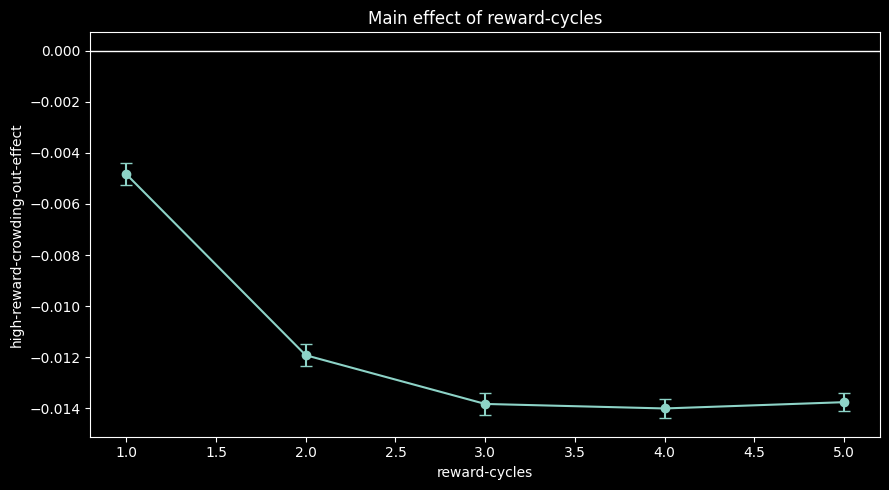

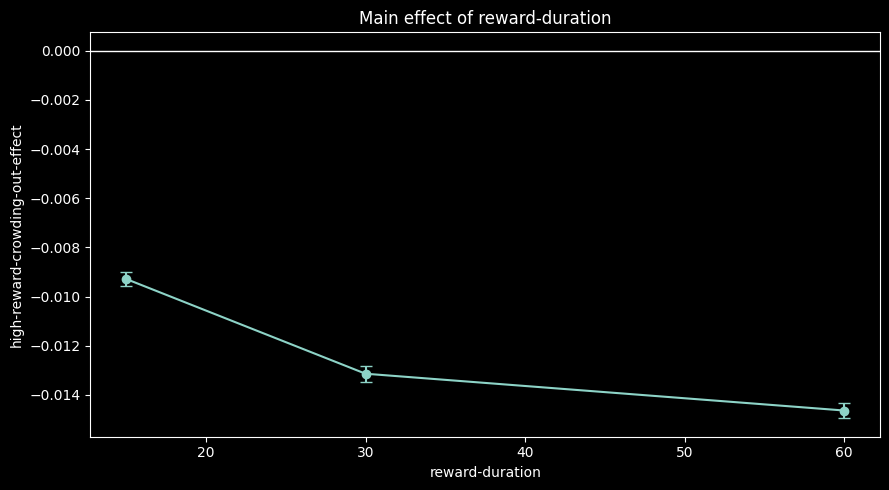

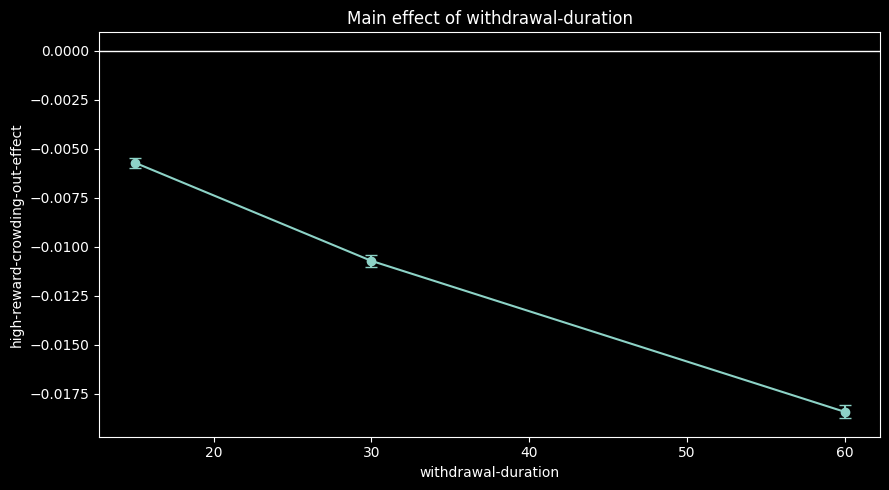

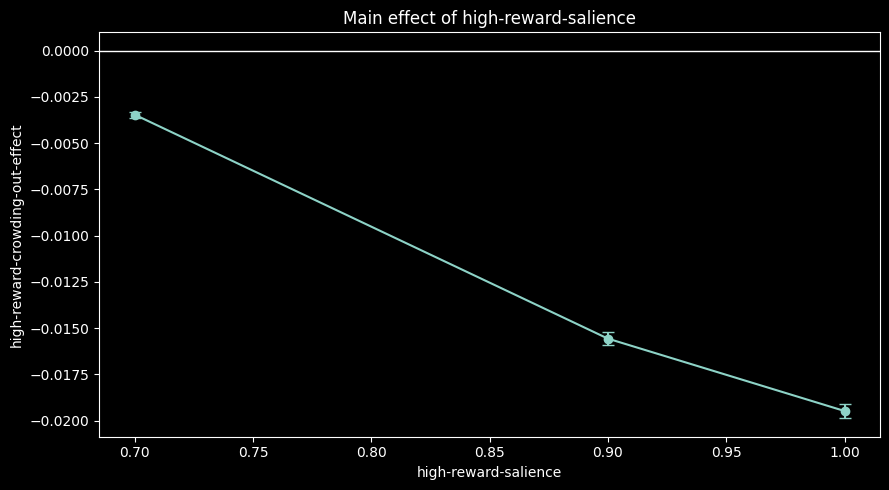

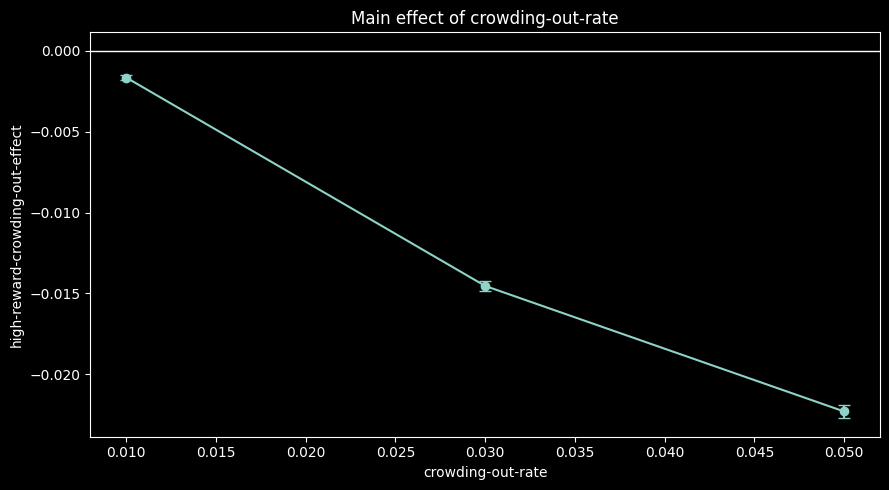

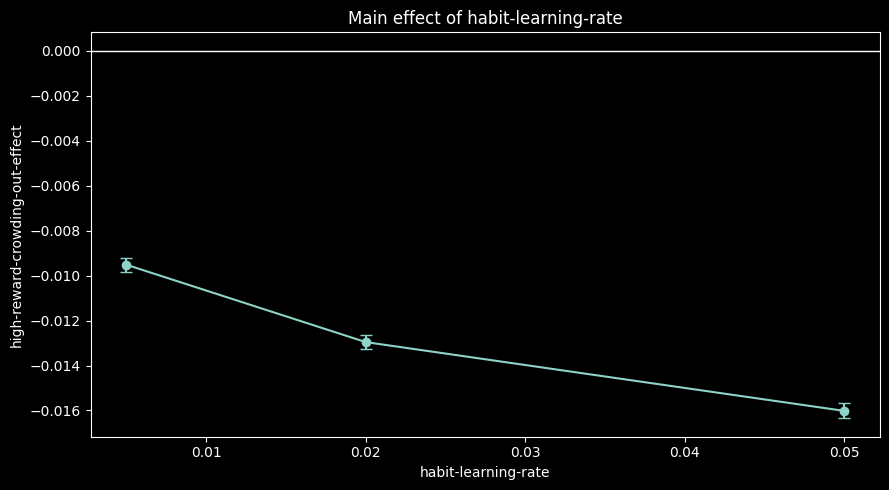

In [11]:
main_effect_tables = {}
for factor in BASE_FACTORS:
    main_effect_tables[factor] = plot_main_effect(clean_df, factor, PRIMARY_TARGET)

## Derived schedule effects

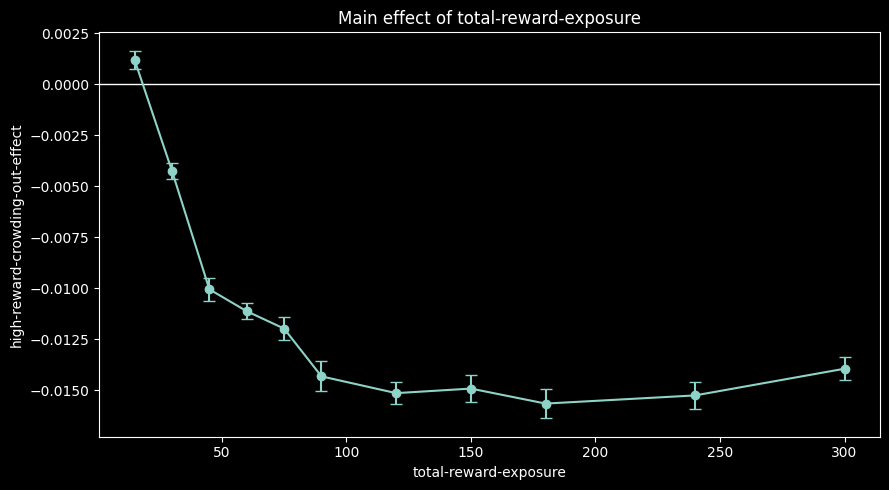

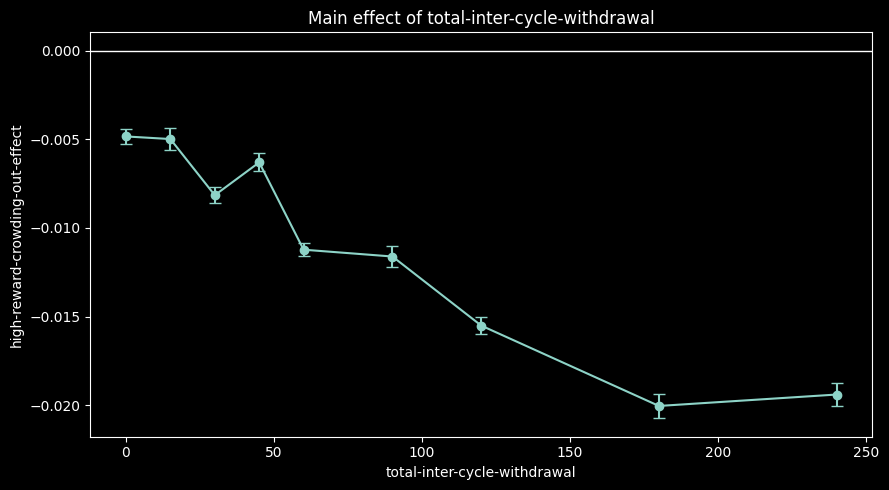

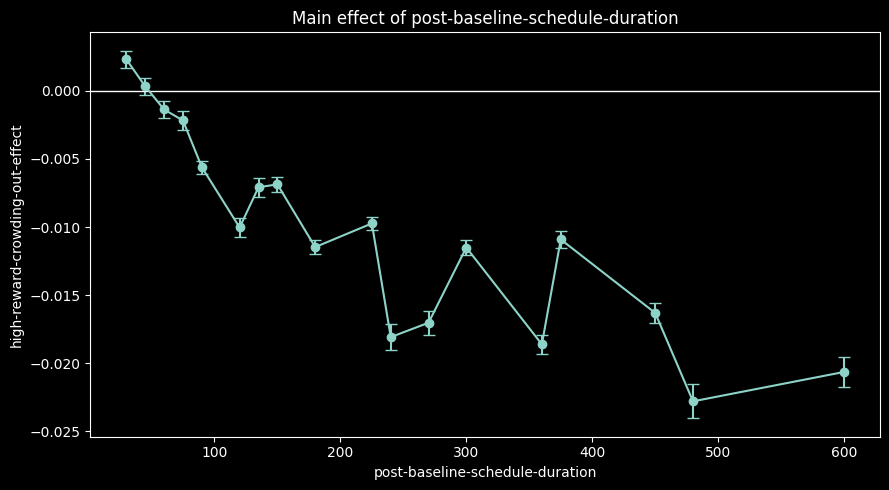

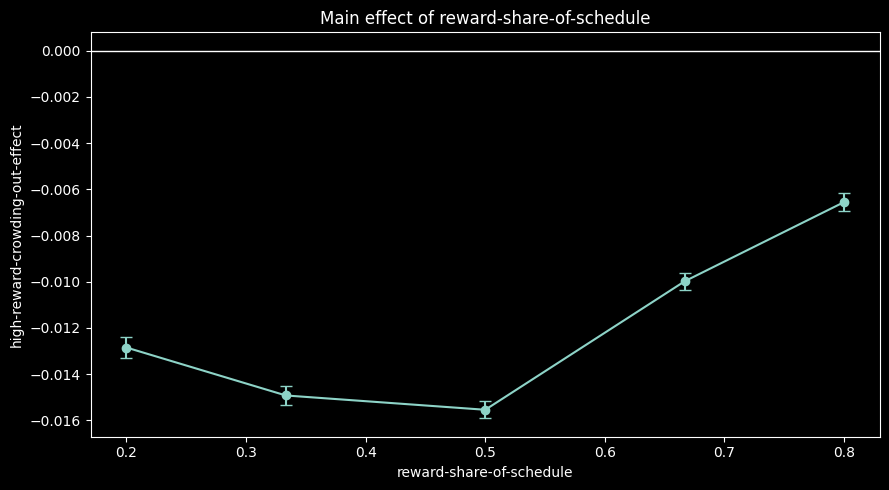

In [12]:
derived_effect_tables = {}
for factor in DERIVED_FACTORS:
    derived_effect_tables[factor] = plot_main_effect(clean_df, factor, PRIMARY_TARGET)

## Ключові interactions

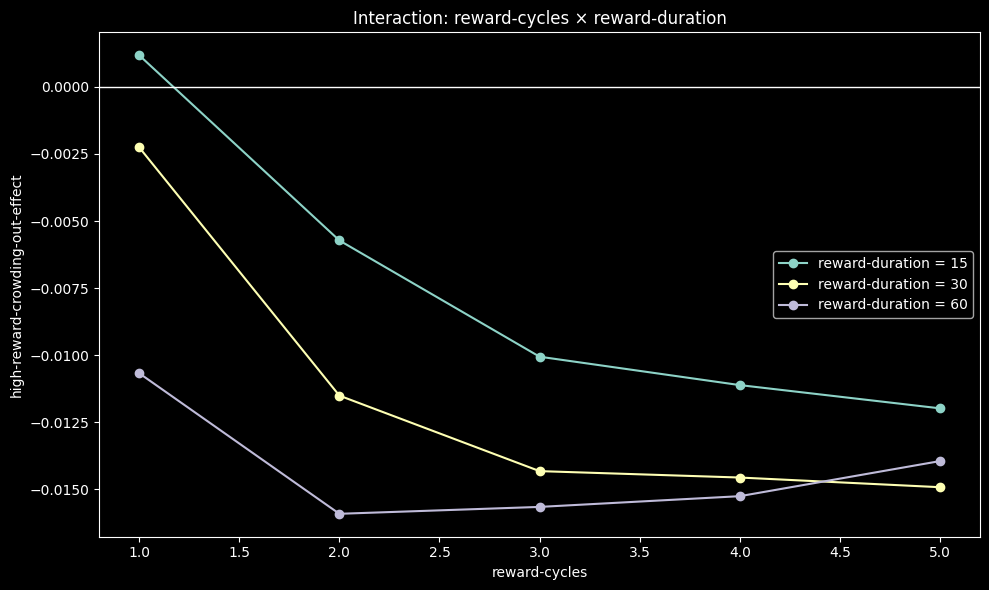

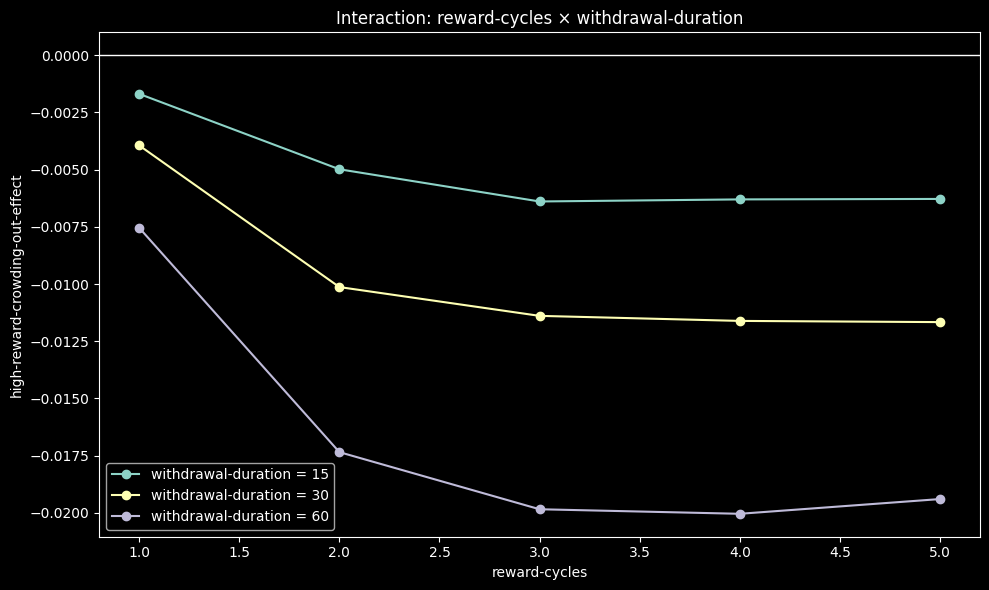

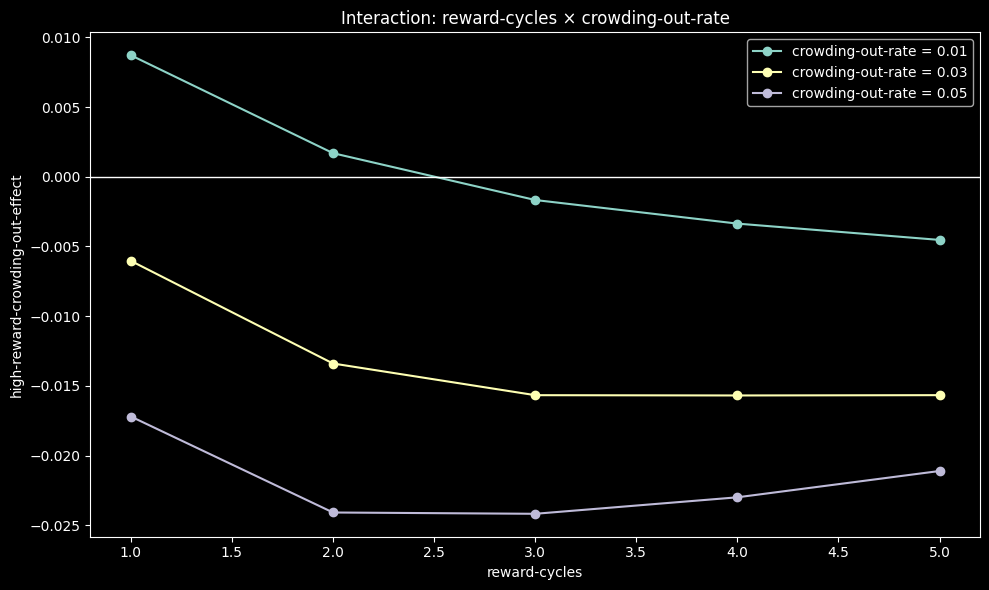

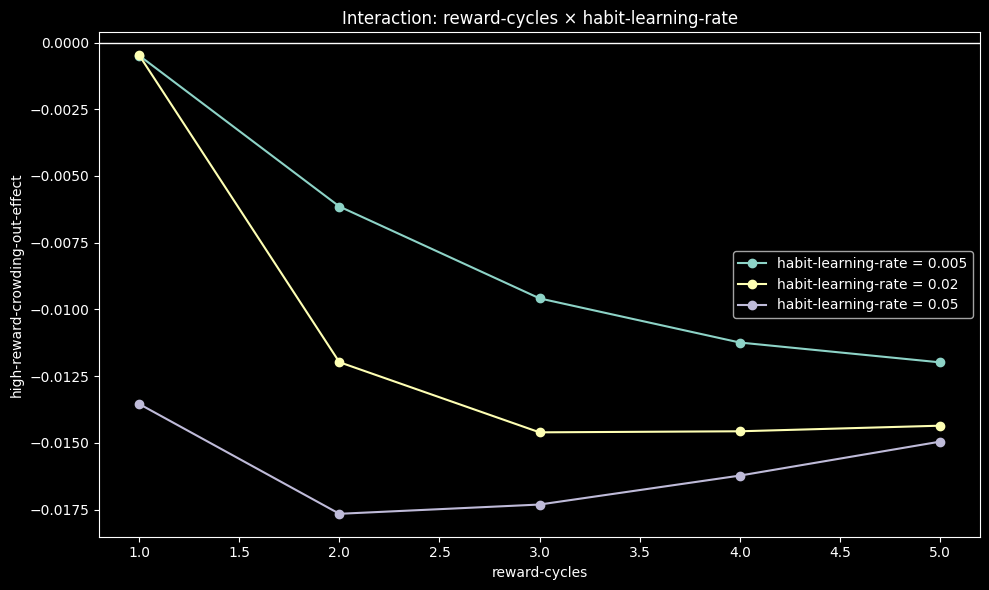

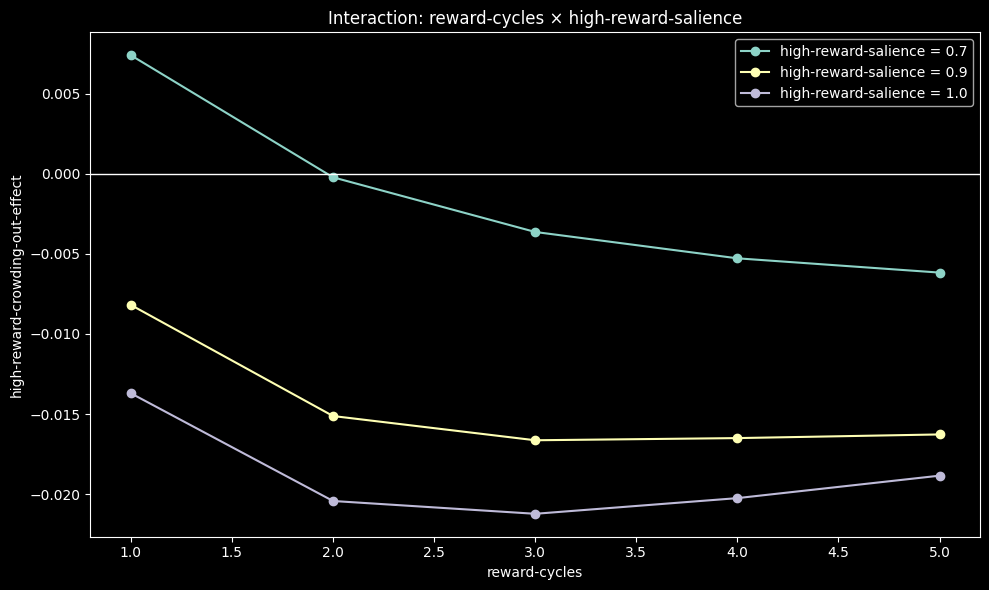

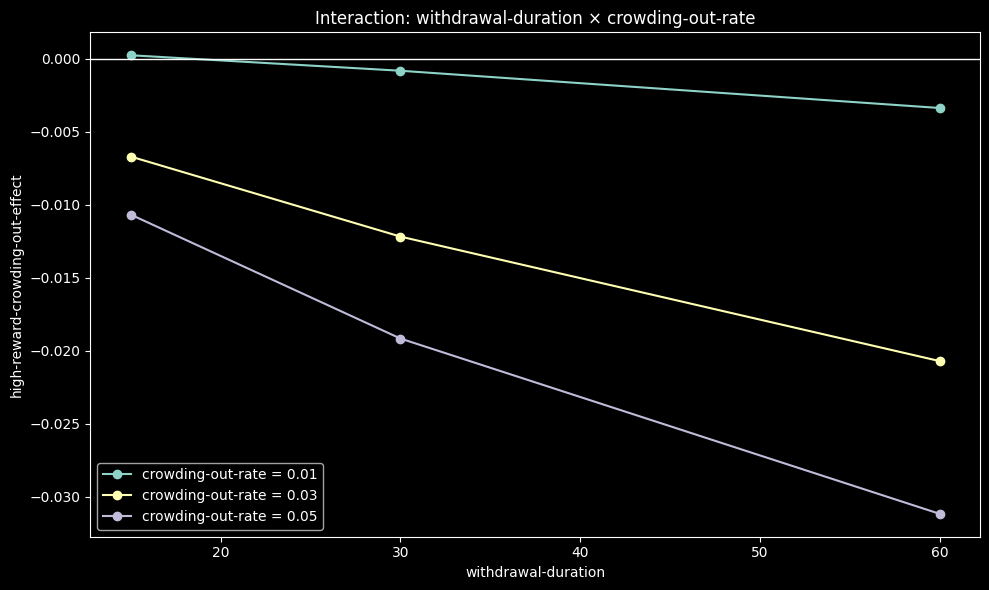

In [13]:
interaction_cycles_duration = plot_interaction(clean_df, "reward-cycles", "reward-duration", PRIMARY_TARGET)
interaction_cycles_withdrawal = plot_interaction(clean_df, "reward-cycles", "withdrawal-duration", PRIMARY_TARGET)
interaction_cycles_crowding = plot_interaction(clean_df, "reward-cycles", "crowding-out-rate", PRIMARY_TARGET)
interaction_cycles_habit = plot_interaction(clean_df, "reward-cycles", "habit-learning-rate", PRIMARY_TARGET)
interaction_cycles_salience = plot_interaction(clean_df, "reward-cycles", "high-reward-salience", PRIMARY_TARGET)
interaction_withdrawal_crowding = plot_interaction(clean_df, "withdrawal-duration", "crowding-out-rate", PRIMARY_TARGET)

## Heatmaps

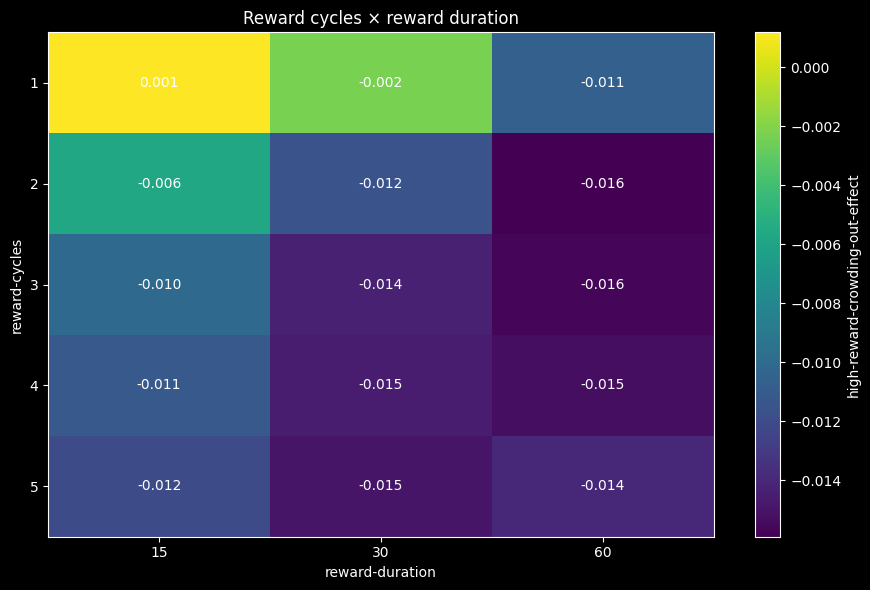

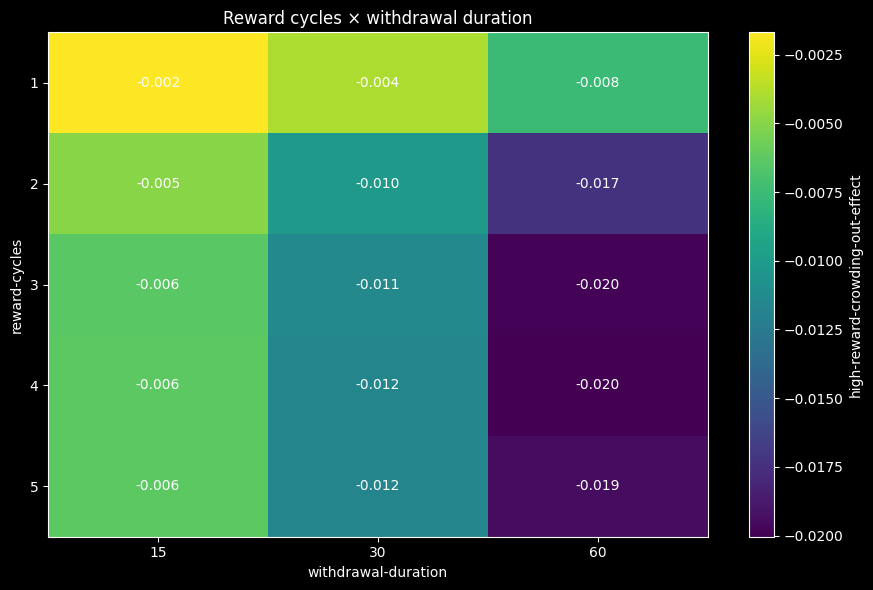

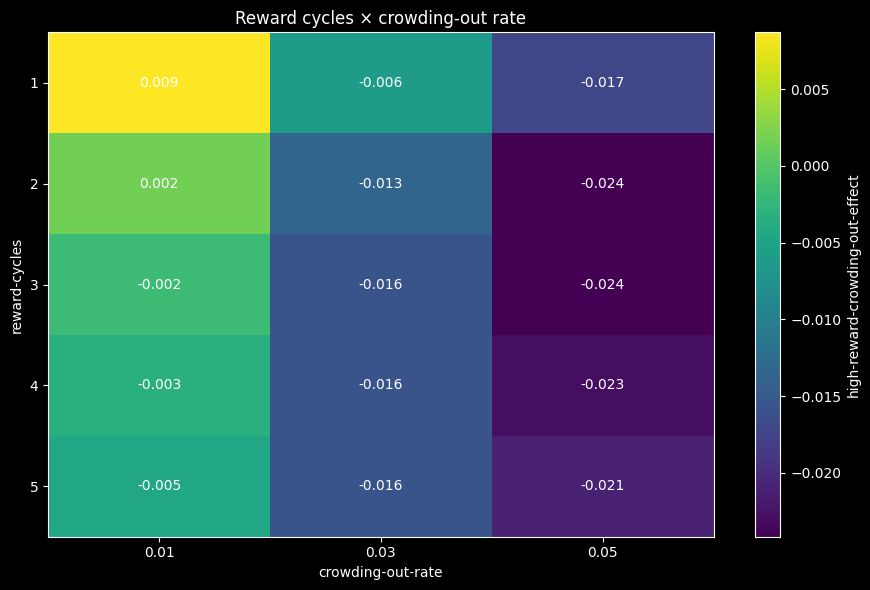

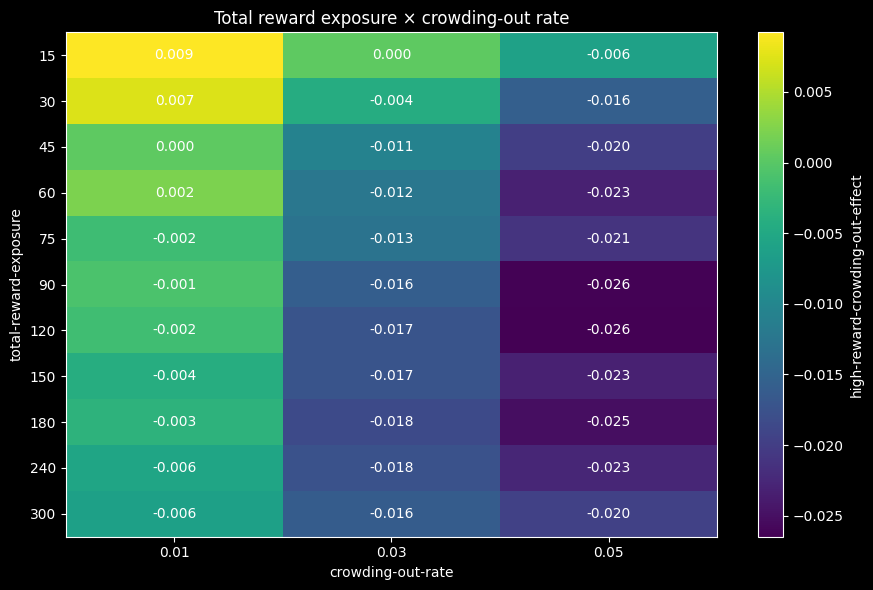

In [14]:
heatmap_cycles_duration = heatmap_table(clean_df, "reward-cycles", "reward-duration", PRIMARY_TARGET, "Reward cycles × reward duration", "heatmap_cycles_vs_duration.png")
heatmap_cycles_withdrawal = heatmap_table(clean_df, "reward-cycles", "withdrawal-duration", PRIMARY_TARGET, "Reward cycles × withdrawal duration", "heatmap_cycles_vs_withdrawal.png")
heatmap_cycles_crowding = heatmap_table(clean_df, "reward-cycles", "crowding-out-rate", PRIMARY_TARGET, "Reward cycles × crowding-out rate", "heatmap_cycles_vs_crowding.png")
heatmap_exposure_crowding = heatmap_table(clean_df, "total-reward-exposure", "crowding-out-rate", PRIMARY_TARGET, "Total reward exposure × crowding-out rate", "heatmap_exposure_vs_crowding.png")

## Поведінкові метрики за кількістю циклів

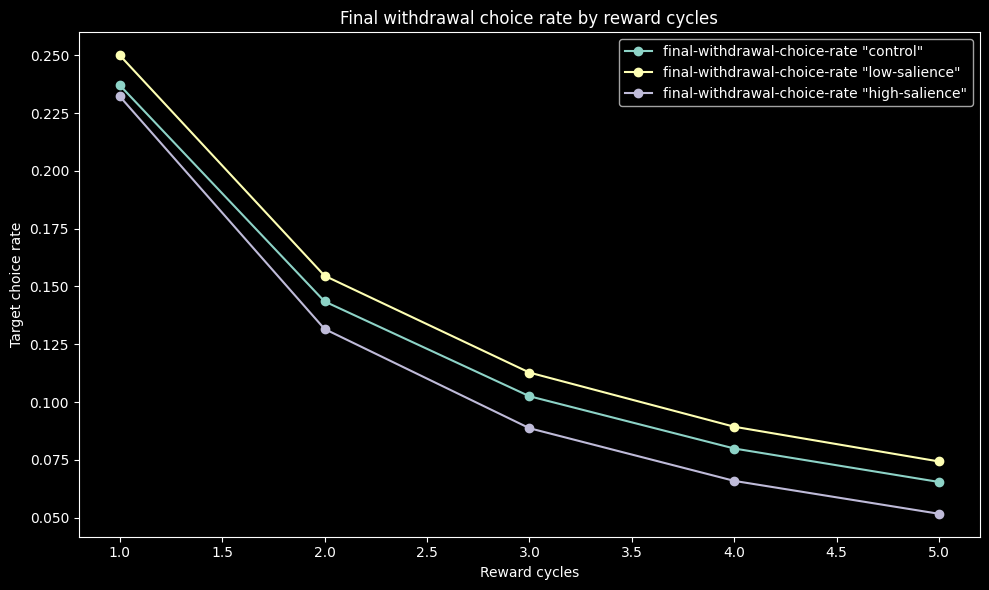

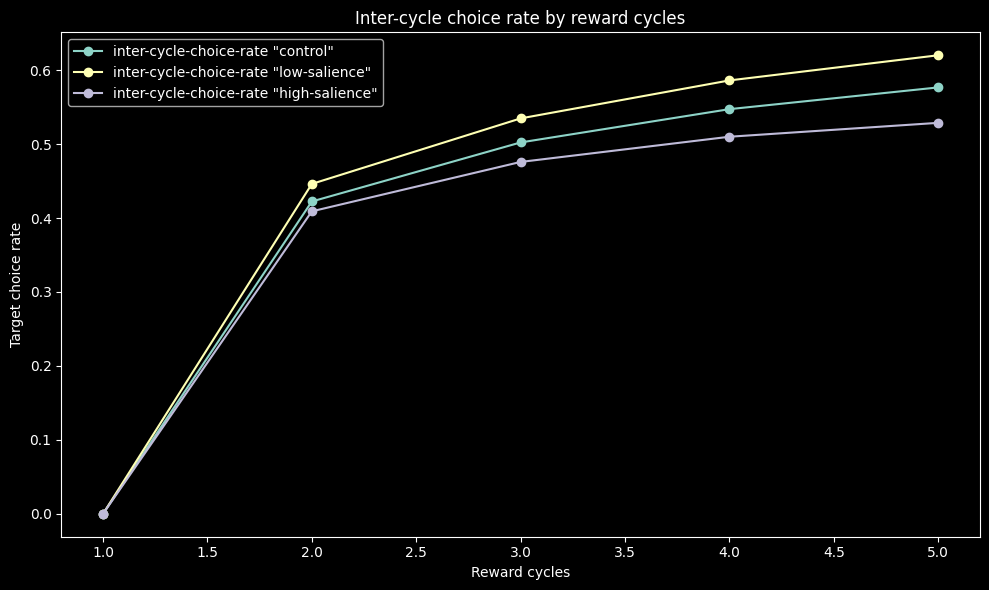

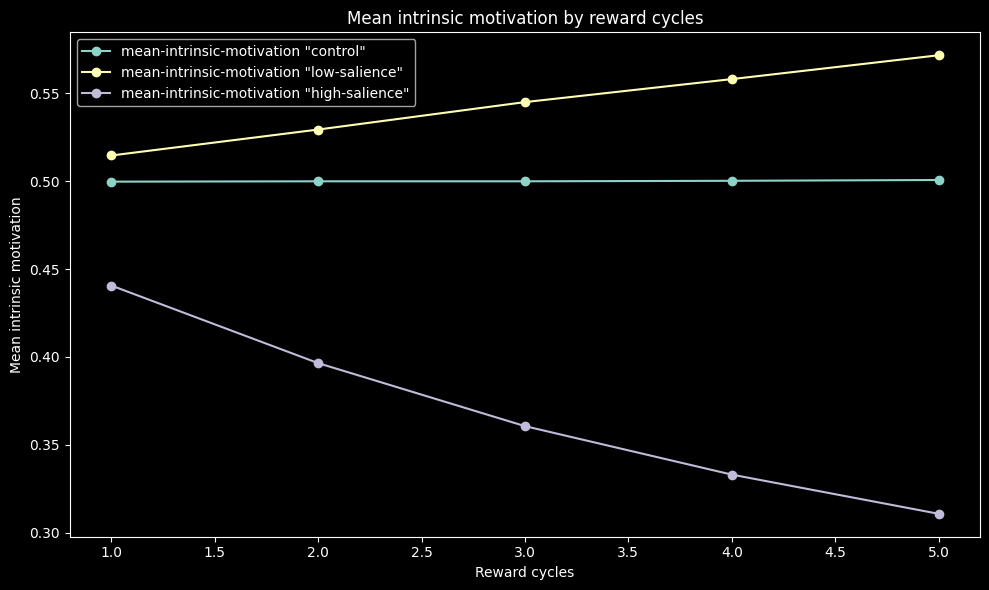

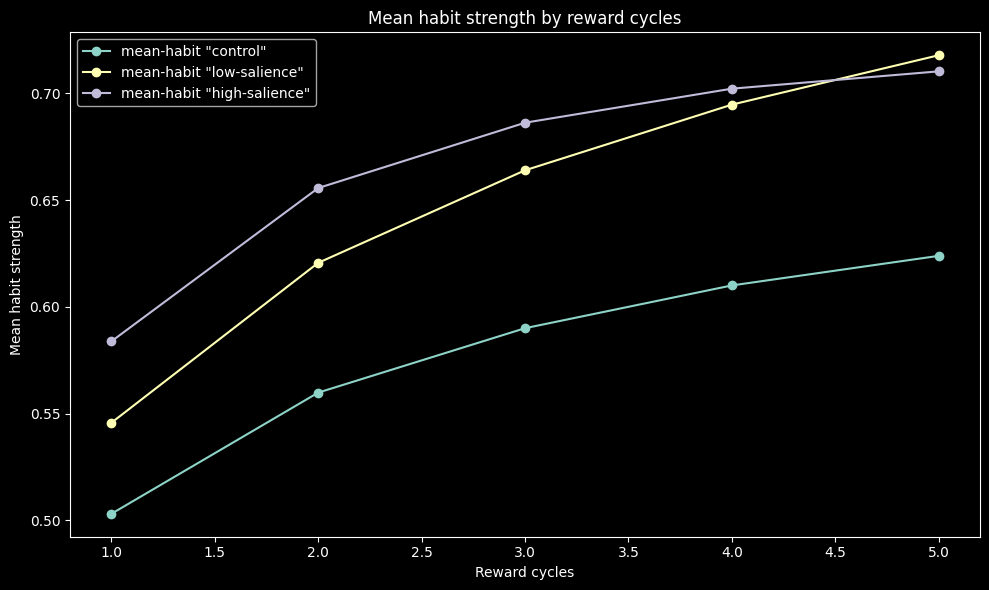

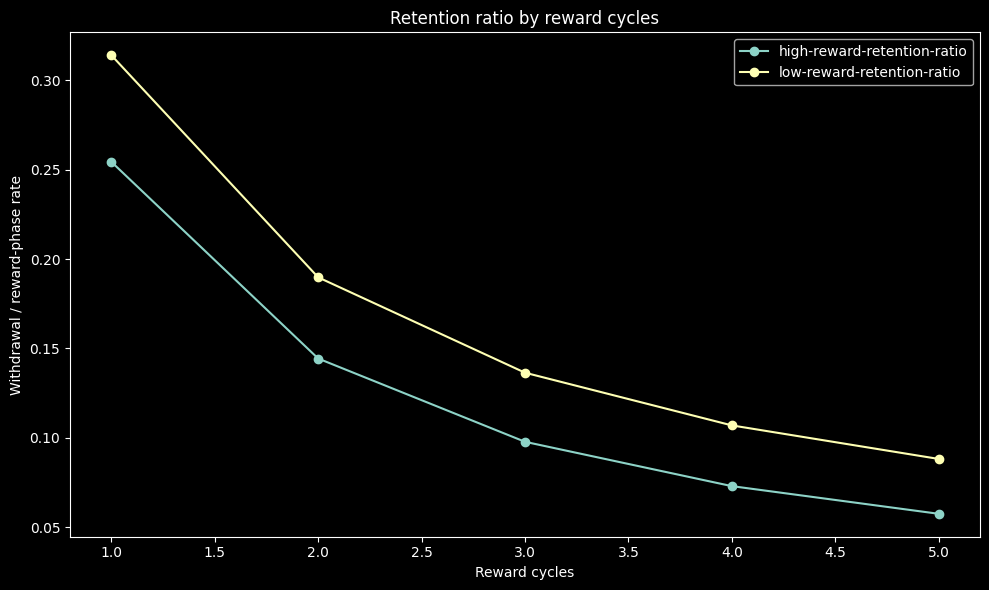

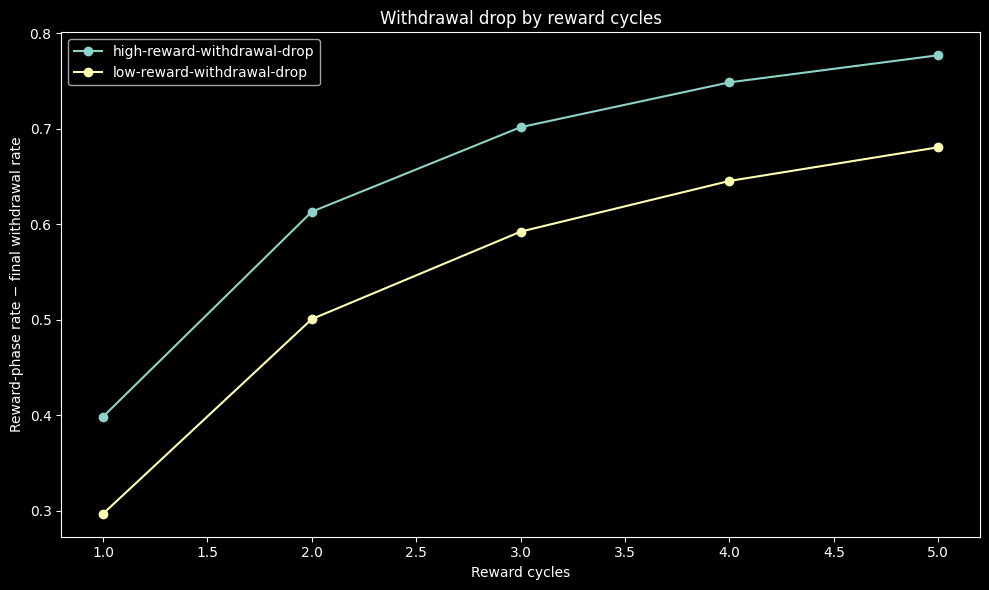

In [15]:
def plot_metric_group(metrics, title, ylabel, filename):
    summary = clean_df.groupby("reward-cycles")[metrics].mean().reset_index()
    fig, ax = plt.subplots(figsize=(10, 6))
    for metric in metrics:
        ax.plot(summary["reward-cycles"], summary[metric], marker="o", label=metric)
    ax.set_title(title)
    ax.set_xlabel("Reward cycles")
    ax.set_ylabel(ylabel)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()
    return summary

final_rate_summary = plot_metric_group(FINAL_WITHDRAWAL_METRICS, "Final withdrawal choice rate by reward cycles", "Target choice rate", "final_withdrawal_rates_by_cycles.png")
inter_cycle_summary = plot_metric_group(INTER_CYCLE_METRICS, "Inter-cycle choice rate by reward cycles", "Target choice rate", "inter_cycle_rates_by_cycles.png")
motivation_summary = plot_metric_group(MOTIVATION_METRICS, "Mean intrinsic motivation by reward cycles", "Mean intrinsic motivation", "intrinsic_motivation_by_cycles.png")
habit_summary = plot_metric_group(HABIT_METRICS, "Mean habit strength by reward cycles", "Mean habit strength", "habit_strength_by_cycles.png")
retention_summary = plot_metric_group(RETENTION_METRICS, "Retention ratio by reward cycles", "Withdrawal / reward-phase rate", "retention_ratio_by_cycles.png")
withdrawal_drop_summary = plot_metric_group(WITHDRAWAL_DROP_METRICS, "Withdrawal drop by reward cycles", "Reward-phase rate − final withdrawal rate", "withdrawal_drop_by_cycles.png")

## Factorial ANOVA

In [16]:
anova_df = clean_df.rename(columns={
    "reward-cycles": "reward_cycles",
    "reward-duration": "reward_duration",
    "withdrawal-duration": "withdrawal_duration",
    "high-reward-salience": "high_reward_salience",
    "crowding-out-rate": "crowding_out_rate",
    "habit-learning-rate": "habit_learning_rate",
    PRIMARY_TARGET: "crowding_effect",
})

formula = (
    "crowding_effect ~ "
    "C(reward_cycles) + C(reward_duration) + C(withdrawal_duration) + "
    "C(high_reward_salience) + C(crowding_out_rate) + C(habit_learning_rate) + "
    "C(reward_cycles):C(reward_duration) + "
    "C(reward_cycles):C(withdrawal_duration) + "
    "C(reward_cycles):C(high_reward_salience) + "
    "C(reward_cycles):C(crowding_out_rate) + "
    "C(reward_cycles):C(habit_learning_rate) + "
    "C(reward_duration):C(crowding_out_rate) + "
    "C(withdrawal_duration):C(crowding_out_rate) + "
    "C(high_reward_salience):C(crowding_out_rate)"
)

anova_model = smf.ols(formula, data=anova_df).fit()
anova_table = anova_lm(anova_model, typ=2)
anova_table["eta_squared"] = anova_table["sum_sq"] / anova_table["sum_sq"].sum()
anova_table = anova_table.sort_values("eta_squared", ascending=False)
anova_table.to_csv(OUTPUT_DIR / "factorial_anova_repeated_schedule.csv")
anova_table

,sum_sq,df,F,PR(>F),eta_squared
Residual,721.504152,292748.0,NaN,NaN,0.928319
C(crowding_out_rate),21.201978,2.0,4301.317417,0.000000e+00,0.027279
C(high_reward_salience),13.614900,2.0,2762.101053,0.000000e+00,0.017518
C(withdrawal_duration),8.334947,2.0,1690.938964,0.000000e+00,0.010724
C(withdrawal_duration):C(crowding_out_rate),2.412793,4.0,244.745718,2.886794e-210,0.003104
C(habit_learning_rate),2.063004,2.0,418.528567,3.124060e-182,0.002654
C(high_reward_salience):C(crowding_out_rate),1.782378,4.0,180.798541,5.156938e-155,0.002293
C(reward_cycles),1.673828,4.0,169.787609,1.684099e-145,0.002154
C(reward_duration),1.665573,2.0,337.900478,2.635174e-147,0.002143
C(reward_cycles):C(habit_learning_rate),0.861290,8.0,43.683225,1.302080e-70,0.001108


## Random Forest та permutation importance

In [17]:
X = clean_df[BASE_FACTORS].copy()
y = clean_df[PRIMARY_TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=3, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("R²:", round(r2_score(y_test, pred), 4))
print("MAE:", round(mean_absolute_error(y_test, pred), 4))

R²: 0.0744
MAE: 0.0255


In [18]:
permutation = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42, scoring="r2", n_jobs=1)
importance_df = pd.DataFrame({
    "parameter": BASE_FACTORS,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std,
}).sort_values("importance_mean", ascending=False)
importance_df.to_csv(OUTPUT_DIR / "permutation_importance_repeated_schedule.csv", index=False)
importance_df

,parameter,importance_mean,importance_std
4,crowding-out-rate,0.071571,0.001690
3,high-reward-salience,0.048410,0.001225
2,withdrawal-duration,0.034100,0.001323
0,reward-cycles,0.015095,0.000553
1,reward-duration,0.012182,0.000702
5,habit-learning-rate,0.011323,0.000514


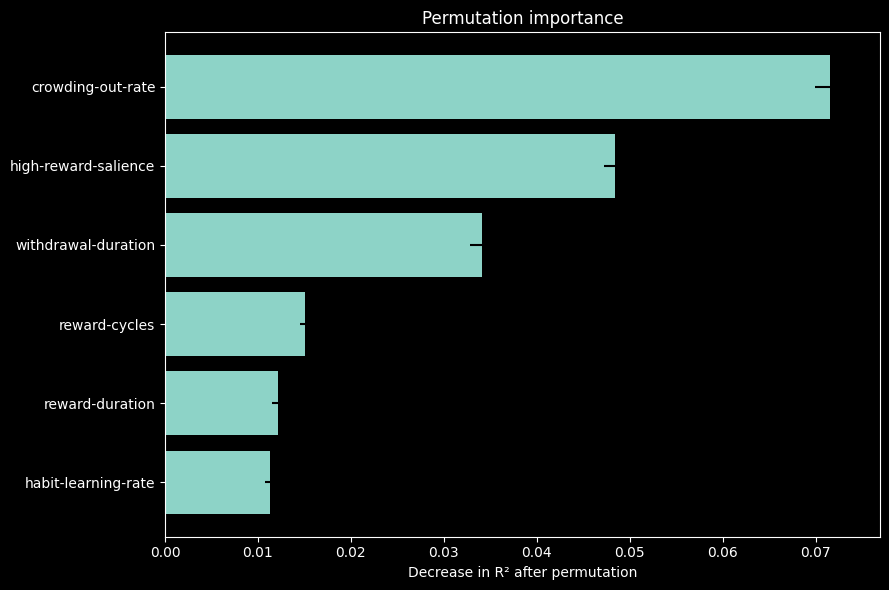

In [19]:
ordered = importance_df.sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(ordered["parameter"], ordered["importance_mean"], xerr=ordered["importance_std"])
ax.set_title("Permutation importance")
ax.set_xlabel("Decrease in R² after permutation")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "permutation_importance.png", dpi=200)
plt.show()

## Partial dependence

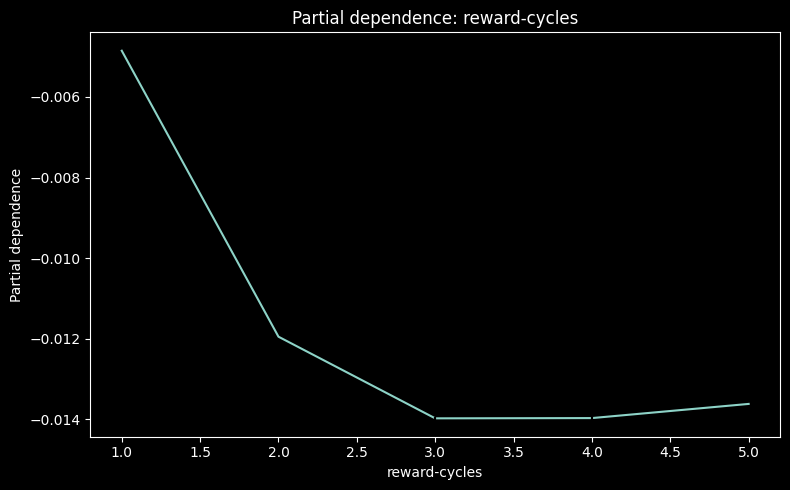

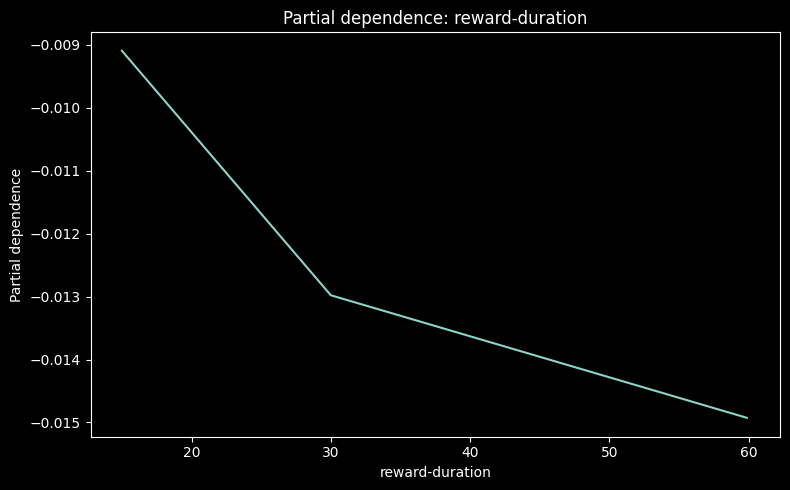

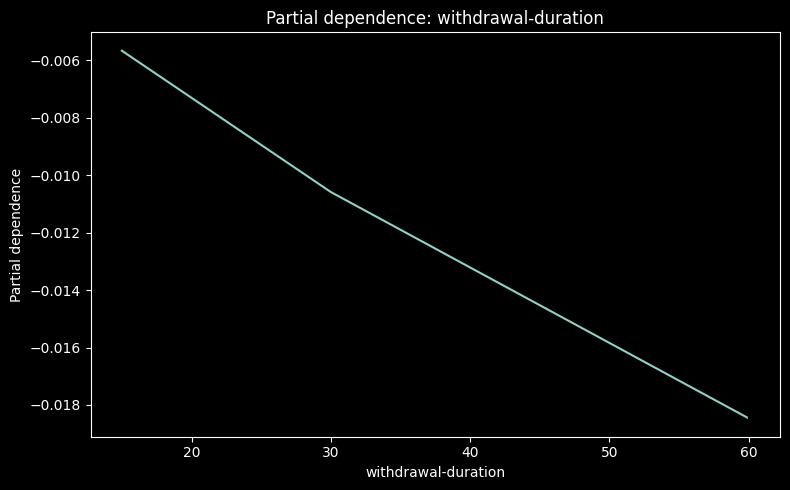

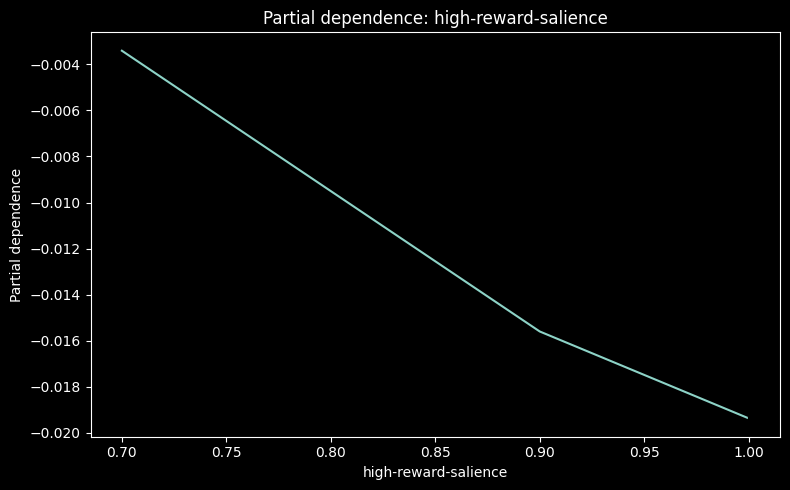

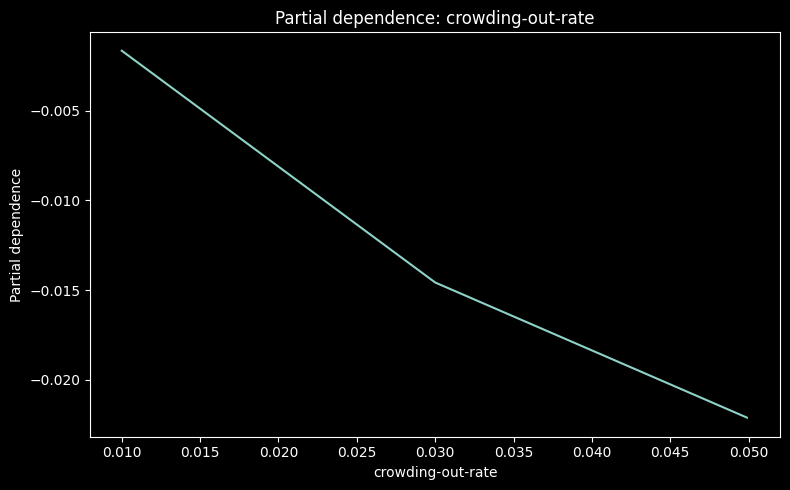

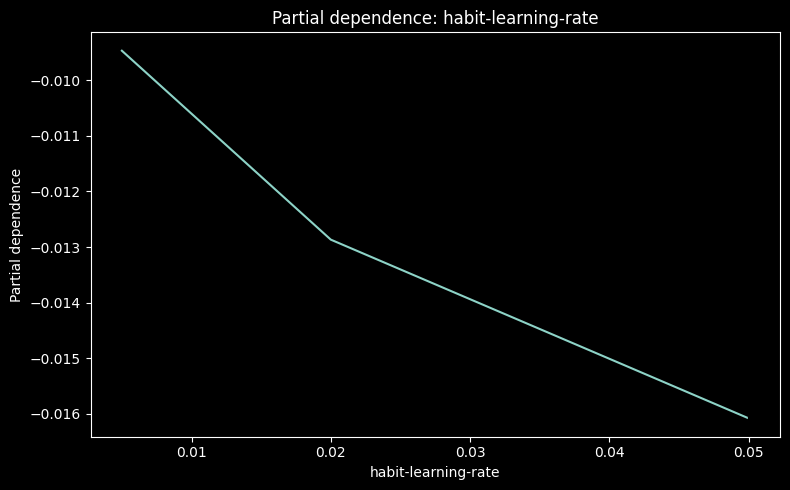

In [20]:
for factor in BASE_FACTORS:
    fig, ax = plt.subplots(figsize=(8, 5))
    PartialDependenceDisplay.from_estimator(rf, X_train, [factor], ax=ax)
    ax.set_title(f"Partial dependence: {factor}")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"partial_dependence_{factor}.png", dpi=200)
    plt.show()

## Scenario summary

In [21]:
scenario_summary = (
    clean_df.groupby(BASE_FACTORS)
    .agg(
        mean_crowding_effect=(PRIMARY_TARGET, "mean"),
        std_crowding_effect=(PRIMARY_TARGET, "std"),
        mean_low_persistence=(SECONDARY_TARGET, "mean"),
        mean_high_final_rate=('final-withdrawal-choice-rate "high-salience"', "mean"),
        mean_low_final_rate=('final-withdrawal-choice-rate "low-salience"', "mean"),
        mean_high_intrinsic=('mean-intrinsic-motivation "high-salience"', "mean"),
        mean_low_intrinsic=('mean-intrinsic-motivation "low-salience"', "mean"),
        mean_high_habit=('mean-habit "high-salience"', "mean"),
        mean_low_habit=('mean-habit "low-salience"', "mean"),
        mean_high_retention=("high-reward-retention-ratio", "mean"),
        mean_high_withdrawal_drop=("high-reward-withdrawal-drop", "mean"),
        crowding_probability=(PRIMARY_TARGET, lambda v: (v < 0).mean()),
        runs=(PRIMARY_TARGET, "size"),
    )
    .reset_index()
)

scenario_summary["total-reward-exposure"] = scenario_summary["reward-cycles"] * scenario_summary["reward-duration"]
scenario_summary["total-inter-cycle-withdrawal"] = (scenario_summary["reward-cycles"] - 1) * scenario_summary["withdrawal-duration"]
scenario_summary["post-baseline-schedule-duration"] = scenario_summary["reward-cycles"] * (scenario_summary["reward-duration"] + scenario_summary["withdrawal-duration"])
scenario_summary.to_csv(OUTPUT_DIR / "scenario_summary_repeated_schedule.csv", index=False)
scenario_summary.head()

,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_final_rate,mean_low_final_rate,mean_high_intrinsic,mean_low_intrinsic,mean_high_habit,mean_low_habit,mean_high_retention,mean_high_withdrawal_drop,crowding_probability,runs,total-reward-exposure,total-inter-cycle-withdrawal,post-baseline-schedule-duration
0,1,15,15,0.7,0.01,0.005,0.012728,0.022690,0.005590,0.146542,0.139404,0.499702,0.507028,0.215246,0.187636,0.174114,0.266573,0.000000,61,15,0,30
1,1,15,15,0.7,0.01,0.020,0.010440,0.018874,0.005609,0.176537,0.171706,0.484443,0.496776,0.487467,0.444124,0.199639,0.256483,0.000000,61,15,0,30
2,1,15,15,0.7,0.01,0.050,0.004568,0.008289,0.005464,0.197006,0.197903,0.505696,0.522454,0.732398,0.716822,0.212216,0.260409,0.000000,61,15,0,30
3,1,15,15,0.7,0.03,0.005,0.009417,0.017732,0.007385,0.144330,0.142299,0.494336,0.503166,0.218480,0.199617,0.171283,0.268180,0.000000,61,15,0,30
4,1,15,15,0.7,0.03,0.020,-0.000854,0.003817,0.001446,0.170409,0.172708,0.482411,0.505161,0.470692,0.454183,0.193717,0.260068,0.180328,61,15,0,30


## Найкращі та найгірші сценарії

In [22]:
print("Strongest crowding-out:")
display(scenario_summary.sort_values("mean_crowding_effect").head(15))

print("Best post-program effect:")
display(scenario_summary.sort_values("mean_crowding_effect", ascending=False).head(15))

Strongest crowding-out:


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_final_rate,mean_low_final_rate,mean_high_intrinsic,mean_low_intrinsic,mean_high_habit,mean_low_habit,mean_high_retention,mean_high_withdrawal_drop,crowding_probability,runs,total-reward-exposure,total-inter-cycle-withdrawal,post-baseline-schedule-duration
242,1,60,60,1.0,0.05,0.050,-0.076235,0.094488,0.009545,0.238633,0.324414,0.275624,0.521713,0.858266,0.867899,0.253288,0.512973,0.397351,151,60,0,120
233,1,60,60,0.9,0.05,0.050,-0.063667,0.078741,0.008278,0.254841,0.326786,0.328222,0.531015,0.868938,0.868949,0.272562,0.490261,0.397351,151,60,0,120
485,2,60,60,1.0,0.05,0.050,-0.060706,0.114239,0.011640,0.115701,0.188047,0.189045,0.553595,0.896459,0.917978,0.125431,0.712678,0.221402,271,120,60,240
484,2,60,60,1.0,0.05,0.020,-0.060304,0.113477,0.017950,0.109542,0.187797,0.190507,0.554821,0.788035,0.804283,0.120520,0.704999,0.221402,271,120,60,240
240,1,60,60,1.0,0.05,0.005,-0.058315,0.073108,0.030118,0.164451,0.252884,0.295016,0.523940,0.327669,0.268374,0.188207,0.534230,0.397351,151,60,0,120
241,1,60,60,1.0,0.05,0.020,-0.055441,0.069279,0.025933,0.235884,0.317259,0.291196,0.532008,0.730790,0.702417,0.253836,0.504422,0.397351,151,60,0,120
476,2,60,60,0.9,0.05,0.050,-0.055429,0.104212,0.010365,0.121943,0.187736,0.236915,0.554808,0.901586,0.918025,0.132702,0.702408,0.221402,271,120,60,240
161,1,30,60,1.0,0.05,0.050,-0.055348,0.056299,0.006624,0.338498,0.400470,0.356051,0.511011,0.838145,0.837882,0.355172,0.371042,0.495868,121,30,0,90
404,2,30,60,1.0,0.05,0.050,-0.055130,0.087798,0.012153,0.168217,0.235500,0.286401,0.525922,0.883485,0.894705,0.178985,0.638758,0.284360,211,60,60,180
403,2,30,60,1.0,0.05,0.020,-0.054911,0.087644,0.011188,0.163712,0.229811,0.291726,0.522718,0.748532,0.742964,0.177115,0.627517,0.284360,211,60,60,180


Best post-program effect:


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_final_rate,mean_low_final_rate,mean_high_intrinsic,mean_low_intrinsic,mean_high_habit,mean_low_habit,mean_high_retention,mean_high_withdrawal_drop,crowding_probability,runs,total-reward-exposure,total-inter-cycle-withdrawal,post-baseline-schedule-duration
225,1,60,60,0.9,0.01,0.005,0.031170,0.038686,0.034912,0.250224,0.253965,0.463269,0.531157,0.377624,0.259176,0.279675,0.458517,0.0,151,60,0,120
136,1,30,60,0.7,0.01,0.020,0.030422,0.031648,0.030621,0.374042,0.374242,0.488702,0.520533,0.667973,0.635577,0.416994,0.290012,0.0,121,30,0,90
234,1,60,60,1.0,0.01,0.005,0.029120,0.037834,0.033498,0.244204,0.248582,0.440689,0.525686,0.386100,0.265750,0.268515,0.478139,0.0,151,60,0,120
216,1,60,60,0.7,0.01,0.005,0.028237,0.035053,0.020530,0.253367,0.245660,0.485660,0.512235,0.344043,0.244794,0.296455,0.423051,0.0,151,60,0,120
189,1,60,30,0.7,0.01,0.005,0.027830,0.048707,0.021813,0.162265,0.156248,0.490214,0.516978,0.332803,0.247627,0.189794,0.470506,0.0,121,60,0,90
139,1,30,60,0.7,0.03,0.020,0.024918,0.027673,0.023156,0.374363,0.372601,0.482817,0.514716,0.667734,0.629272,0.412973,0.297365,0.0,121,30,0,90
219,1,60,60,0.7,0.03,0.005,0.023371,0.029329,0.028872,0.238239,0.243741,0.459913,0.507726,0.328381,0.244342,0.282293,0.431402,0.0,151,60,0,120
73,1,15,60,1.0,0.01,0.020,0.023161,0.022010,0.018021,0.412678,0.407538,0.482104,0.502777,0.620971,0.579344,0.441966,0.246708,0.0,106,15,0,75
55,1,15,60,0.7,0.01,0.020,0.022966,0.021062,0.004696,0.418328,0.400058,0.511110,0.507115,0.617311,0.575506,0.465171,0.216611,0.0,106,15,0,75
153,1,30,60,1.0,0.01,0.005,0.022578,0.023292,0.018000,0.294211,0.289632,0.474246,0.514178,0.302032,0.215592,0.326392,0.375241,0.0,121,30,0,90


## Стабільні режими

In [23]:
stable_crowding = scenario_summary[(scenario_summary["mean_crowding_effect"] < 0) & (scenario_summary["crowding_probability"] >= 0.80)].sort_values(["crowding_probability", "mean_crowding_effect"], ascending=[False, True])
stable_persistence = scenario_summary[(scenario_summary["mean_crowding_effect"] > 0) & (scenario_summary["crowding_probability"] <= 0.20)].sort_values("mean_crowding_effect", ascending=False)
print("Stable crowding-out scenarios:", len(stable_crowding))
display(stable_crowding.head(20))
print("Stable persistence scenarios:", len(stable_persistence))
display(stable_persistence.head(20))

Stable crowding-out scenarios: 0


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_final_rate,mean_low_final_rate,mean_high_intrinsic,mean_low_intrinsic,mean_high_habit,mean_low_habit,mean_high_retention,mean_high_withdrawal_drop,crowding_probability,runs,total-reward-exposure,total-inter-cycle-withdrawal,post-baseline-schedule-duration


Stable persistence scenarios: 312


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_final_rate,mean_low_final_rate,mean_high_intrinsic,mean_low_intrinsic,mean_high_habit,mean_low_habit,mean_high_retention,mean_high_withdrawal_drop,crowding_probability,runs,total-reward-exposure,total-inter-cycle-withdrawal,post-baseline-schedule-duration
225,1,60,60,0.9,0.01,0.005,0.031170,0.038686,0.034912,0.250224,0.253965,0.463269,0.531157,0.377624,0.259176,0.279675,0.458517,0.0,151,60,0,120
136,1,30,60,0.7,0.01,0.020,0.030422,0.031648,0.030621,0.374042,0.374242,0.488702,0.520533,0.667973,0.635577,0.416994,0.290012,0.0,121,30,0,90
234,1,60,60,1.0,0.01,0.005,0.029120,0.037834,0.033498,0.244204,0.248582,0.440689,0.525686,0.386100,0.265750,0.268515,0.478139,0.0,151,60,0,120
216,1,60,60,0.7,0.01,0.005,0.028237,0.035053,0.020530,0.253367,0.245660,0.485660,0.512235,0.344043,0.244794,0.296455,0.423051,0.0,151,60,0,120
189,1,60,30,0.7,0.01,0.005,0.027830,0.048707,0.021813,0.162265,0.156248,0.490214,0.516978,0.332803,0.247627,0.189794,0.470506,0.0,121,60,0,90
139,1,30,60,0.7,0.03,0.020,0.024918,0.027673,0.023156,0.374363,0.372601,0.482817,0.514716,0.667734,0.629272,0.412973,0.297365,0.0,121,30,0,90
219,1,60,60,0.7,0.03,0.005,0.023371,0.029329,0.028872,0.238239,0.243741,0.459913,0.507726,0.328381,0.244342,0.282293,0.431402,0.0,151,60,0,120
73,1,15,60,1.0,0.01,0.020,0.023161,0.022010,0.018021,0.412678,0.407538,0.482104,0.502777,0.620971,0.579344,0.441966,0.246708,0.0,106,15,0,75
55,1,15,60,0.7,0.01,0.020,0.022966,0.021062,0.004696,0.418328,0.400058,0.511110,0.507115,0.617311,0.575506,0.465171,0.216611,0.0,106,15,0,75
153,1,30,60,1.0,0.01,0.005,0.022578,0.023292,0.018000,0.294211,0.289632,0.474246,0.514178,0.302032,0.215592,0.326392,0.375241,0.0,121,30,0,90


## Однакова сумарна reward exposure

In [24]:
exposure_summary = (
    scenario_summary.groupby(["total-reward-exposure", "reward-cycles", "reward-duration"])
    .agg(
        mean_crowding_effect=("mean_crowding_effect", "mean"),
        mean_high_final_rate=("mean_high_final_rate", "mean"),
        mean_high_intrinsic=("mean_high_intrinsic", "mean"),
        mean_high_habit=("mean_high_habit", "mean"),
        scenarios=("mean_crowding_effect", "size"),
    )
    .reset_index()
)
exposure_counts = exposure_summary.groupby("total-reward-exposure").size().reset_index(name="schedule_variants")
comparable = exposure_counts[exposure_counts["schedule_variants"] > 1]["total-reward-exposure"]
equal_exposure_comparisons = exposure_summary[exposure_summary["total-reward-exposure"].isin(comparable)].sort_values(["total-reward-exposure", "reward-cycles"])
equal_exposure_comparisons

,total-reward-exposure,reward-cycles,reward-duration,mean_crowding_effect,mean_high_final_rate,mean_high_intrinsic,mean_high_habit,scenarios
1,30,1,30,-0.002025,0.230873,0.451840,0.565184,81
2,30,2,15,-0.004988,0.167180,0.452468,0.583463,81
4,60,1,60,-0.009974,0.171777,0.413925,0.631896,81
5,60,2,30,-0.010348,0.131545,0.413132,0.638718,81
6,60,4,15,-0.009740,0.089806,0.411637,0.641341,81
9,120,2,60,-0.014719,0.090465,0.355360,0.704812,81
10,120,4,30,-0.013082,0.065991,0.352608,0.691698,81


## Pareto-оптимальні сценарії

In [25]:
pareto_df = scenario_summary.copy()
pareto_df["crowding_penalty"] = -pareto_df["mean_crowding_effect"]
objectives = [
    ("mean_high_final_rate", "max"),
    ("mean_high_intrinsic", "max"),
    ("crowding_penalty", "min"),
    ("total-reward-exposure", "min"),
]

def dominates(a, b):
    no_worse = True
    strictly_better = False
    for column, direction in objectives:
        av, bv = a[column], b[column]
        if direction == "max":
            if av < bv: no_worse = False
            if av > bv: strictly_better = True
        else:
            if av > bv: no_worse = False
            if av < bv: strictly_better = True
    return no_worse and strictly_better

is_pareto = []
for i, row_i in pareto_df.iterrows():
    dominated = any(dominates(row_j, row_i) for j, row_j in pareto_df.iterrows() if i != j)
    is_pareto.append(not dominated)

pareto_df["pareto_optimal"] = is_pareto
pareto_scenarios = pareto_df[pareto_df["pareto_optimal"]].sort_values(["mean_high_final_rate", "mean_high_intrinsic", "total-reward-exposure"], ascending=[False, False, True])
print("Pareto-optimal scenarios:", len(pareto_scenarios))
pareto_scenarios.head(30)

Pareto-optimal scenarios: 9


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_final_rate,mean_low_final_rate,mean_high_intrinsic,mean_low_intrinsic,mean_high_habit,mean_low_habit,mean_high_retention,mean_high_withdrawal_drop,crowding_probability,runs,total-reward-exposure,total-inter-cycle-withdrawal,post-baseline-schedule-duration,crowding_penalty,pareto_optimal
56,1,15,60,0.7,0.01,0.050,0.007647,0.008879,-0.001259,0.452292,0.443386,0.497957,0.500836,0.825722,0.804251,0.489004,0.200867,0.009434,106,15,0,75,-0.007647,True
59,1,15,60,0.7,0.03,0.050,0.009086,0.008799,0.011288,0.451654,0.453856,0.500061,0.513286,0.827977,0.812754,0.487049,0.204356,0.000000,106,15,0,75,-0.009086,True
55,1,15,60,0.7,0.01,0.020,0.022966,0.021062,0.004696,0.418328,0.400058,0.511110,0.507115,0.617311,0.575506,0.465171,0.216611,0.000000,106,15,0,75,-0.022966,True
73,1,15,60,1.0,0.01,0.020,0.023161,0.022010,0.018021,0.412678,0.407538,0.482104,0.502777,0.620971,0.579344,0.441966,0.246708,0.000000,106,15,0,75,-0.023161,True
139,1,30,60,0.7,0.03,0.020,0.024918,0.027673,0.023156,0.374363,0.372601,0.482817,0.514716,0.667734,0.629272,0.412973,0.297365,0.000000,121,30,0,90,-0.024918,True
136,1,30,60,0.7,0.01,0.020,0.030422,0.031648,0.030621,0.374042,0.374242,0.488702,0.520533,0.667973,0.635577,0.416994,0.290012,0.000000,121,30,0,90,-0.030422,True
109,1,30,30,0.7,0.01,0.020,0.019989,0.029301,0.012019,0.251716,0.243745,0.519013,0.501234,0.619039,0.553015,0.277861,0.340623,0.000000,91,30,0,60,-0.019989,True
225,1,60,60,0.9,0.01,0.005,0.031170,0.038686,0.034912,0.250224,0.253965,0.463269,0.531157,0.377624,0.259176,0.279675,0.458517,0.000000,151,60,0,120,-0.031170,True
189,1,60,30,0.7,0.01,0.005,0.027830,0.048707,0.021813,0.162265,0.156248,0.490214,0.516978,0.332803,0.247627,0.189794,0.470506,0.000000,121,60,0,90,-0.027830,True


## Автоматичне резюме

In [26]:
most_important = importance_df.iloc[0]["parameter"]
largest_anova_effect = anova_table.index[0]
best_scenario = scenario_summary.sort_values("mean_crowding_effect", ascending=False).iloc[0]
worst_scenario = scenario_summary.sort_values("mean_crowding_effect").iloc[0]

print("Mean high-reward crowding-out effect:", round(clean_df[PRIMARY_TARGET].mean(), 4))
print("Share of runs with crowding-out:", f"{crowding_share:.1%}")
print("Most important parameter:", most_important)
print("Largest ANOVA effect:", largest_anova_effect)
print("Pareto-optimal scenarios:", len(pareto_scenarios))
print("\nBest parameter combination:")
display(best_scenario.to_frame().T)
print("Worst parameter combination:")
display(worst_scenario.to_frame().T)

Mean high-reward crowding-out effect: -0.0128
Share of runs with crowding-out: 11.2%
Most important parameter: crowding-out-rate
Largest ANOVA effect: Residual
Pareto-optimal scenarios: 9

Best parameter combination:


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_final_rate,mean_low_final_rate,mean_high_intrinsic,mean_low_intrinsic,mean_high_habit,mean_low_habit,mean_high_retention,mean_high_withdrawal_drop,crowding_probability,runs,total-reward-exposure,total-inter-cycle-withdrawal,post-baseline-schedule-duration
225,1.0,60.0,60.0,0.9,0.01,0.005,0.03117,0.038686,0.034912,0.250224,0.253965,0.463269,0.531157,0.377624,0.259176,0.279675,0.458517,0.0,151.0,60.0,0.0,120.0


Worst parameter combination:


,reward-cycles,reward-duration,withdrawal-duration,high-reward-salience,crowding-out-rate,habit-learning-rate,mean_crowding_effect,std_crowding_effect,mean_low_persistence,mean_high_final_rate,mean_low_final_rate,mean_high_intrinsic,mean_low_intrinsic,mean_high_habit,mean_low_habit,mean_high_retention,mean_high_withdrawal_drop,crowding_probability,runs,total-reward-exposure,total-inter-cycle-withdrawal,post-baseline-schedule-duration
242,1.0,60.0,60.0,1.0,0.05,0.05,-0.076235,0.094488,0.009545,0.238633,0.324414,0.275624,0.521713,0.858266,0.867899,0.253288,0.512973,0.397351,151.0,60.0,0.0,120.0


## Експорт результатів

In [27]:
clean_df.to_csv(OUTPUT_DIR / "clean_repeated_schedule_data.csv", index=False)
design_counts.to_csv(OUTPUT_DIR / "design_counts.csv", index=False)
scenario_summary.to_csv(OUTPUT_DIR / "scenario_summary.csv", index=False)
stable_crowding.to_csv(OUTPUT_DIR / "stable_crowding_scenarios.csv", index=False)
stable_persistence.to_csv(OUTPUT_DIR / "stable_persistence_scenarios.csv", index=False)
equal_exposure_comparisons.to_csv(OUTPUT_DIR / "equal_reward_exposure_comparisons.csv", index=False)
pareto_scenarios.to_csv(OUTPUT_DIR / "pareto_optimal_scenarios.csv", index=False)
final_rate_summary.to_csv(OUTPUT_DIR / "final_rate_summary_by_cycles.csv", index=False)
inter_cycle_summary.to_csv(OUTPUT_DIR / "inter_cycle_summary_by_cycles.csv", index=False)
motivation_summary.to_csv(OUTPUT_DIR / "motivation_summary_by_cycles.csv", index=False)
habit_summary.to_csv(OUTPUT_DIR / "habit_summary_by_cycles.csv", index=False)
retention_summary.to_csv(OUTPUT_DIR / "retention_summary_by_cycles.csv", index=False)
withdrawal_drop_summary.to_csv(OUTPUT_DIR / "withdrawal_drop_summary_by_cycles.csv", index=False)
print("Усі результати збережено у:", OUTPUT_DIR.resolve())

Усі результати збережено у: /Users/igor/projects/phd/reward-habits-model/analysis_output/3-repeated-schedule-sensitivity
